In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [23]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Exploring games data

In [24]:
clean_games_fp = Path(config['games_folder'] + config['games_clean_fp'])

games_df = pd.read_json(clean_games_fp, orient='records')
games_df['updated_at'] = pd.to_datetime(games_df['updated_at'], errors='coerce')
games_df['first_release_date'] = pd.to_datetime(games_df['first_release_date'], errors='coerce')

games_df.head()

,name,rating,updated_at,first_release_date,id
0,Stardew Valley,86.163860,2026-05-05 16:05:00,2016-02-26,17000
1,Star Wars Battlefront II,70.385402,2026-05-05 16:04:59,2017-11-17,26401
2,Skull and Bones,50.075148,2026-05-05 16:04:51,2024-02-16,37062
3,Sea of Thieves,71.666843,2026-05-05 16:04:48,2018-03-20,11137
4,Mirror's Edge Catalyst,69.294297,2026-05-05 16:04:13,2016-06-07,2112


In [25]:
games_df.head()

,name,rating,updated_at,first_release_date,id
0,Stardew Valley,86.163860,2026-05-05 16:05:00,2016-02-26,17000
1,Star Wars Battlefront II,70.385402,2026-05-05 16:04:59,2017-11-17,26401
2,Skull and Bones,50.075148,2026-05-05 16:04:51,2024-02-16,37062
3,Sea of Thieves,71.666843,2026-05-05 16:04:48,2018-03-20,11137
4,Mirror's Edge Catalyst,69.294297,2026-05-05 16:04:13,2016-06-07,2112


In [26]:
#Checking to make sure the id uniquely identifies each row
print("No duplicate IDS") if len(games_df['id'].unique()) == len(games_df) else print("Duplicate IDs found")

No duplicate IDS


In [27]:
#Checking to see if duplicate game names exist
print("No duplicate game names") if len(games_df['name'].unique()) == len(games_df) else print("Duplicate game names found")

Duplicate game names found


In [28]:
#Get all rows with duplicate game names
duplicate_names_df = games_df[games_df.duplicated(subset=['name'], keep=False)].sort_values('name')
duplicate_names_df.head(6)

,name,rating,updated_at,first_release_date,id
17083,10-Pin Bowling,-1.000000,2024-11-14 09:33:09,1984-12-31,153453
17084,10-Pin Bowling,-1.000000,2024-11-14 09:27:27,1999-08-01,92273
7778,15 Minutes,-1.000000,2026-04-09 19:38:22,2026-01-05,395433
13072,15 Minutes,-1.000000,2026-02-02 16:52:35,2025-10-23,355071
6551,1942,61.392350,2026-04-18 08:37:59,1985-12-11,272544
7267,1942,67.742592,2026-04-13 08:03:19,1984-12-01,6075


In [29]:
#Find columns where duplicates differ (excluding name, rating, updated_at, id)
exclude_cols = {'name', 'rating', 'updated_at', 'id'}
cols_to_check = [col for col in duplicate_names_df.columns if col not in exclude_cols]

i = 0
for game_name in duplicate_names_df['name'].unique():
    game_group = duplicate_names_df[duplicate_names_df['name'] == game_name]
    differing_cols = []
    for col in cols_to_check:
        if len(game_group[col].unique()) > 1:
            differing_cols.append(col)
    if'first_release_date' not in differing_cols:  # Print every 10th game to avoid too much output
        #print(f"{game_name}: {differing_cols}")
        pass
    i+=1

There are many duplicates but they may functionally differ so we'll keep them for now

## Conflicts in game modes columns

There are several game mode columns that seem to imply multiplayer functionality (such as Co-operative or Massively Multiplayer Online), but we should check if they actually do inherently imply multiplayer compatibility. If not, we should make sure we understand what the column is referring to.

In [31]:
#coop_without_multiplayer = games_df.groupby(['game_modes_Co-operative', 'game_modes_Multiplayer'])[['name', 'first_release_date']].agg(lambda x: x.sample(1))
#coop_without_multiplayer

For co-op, it seems like an error in entry; games with coop should have a 1 in the multiplayer column.

In [33]:
#br_without_multiplayer = games_df.groupby(['game_modes_Battle Royale', 'game_modes_Multiplayer'])[['name', 'first_release_date']].agg(lambda x: x.sample(1))
#br_without_multiplayer

Same for MMO

# Exploring multiplayer modes data

In [34]:
clean_modes_fp = Path(config['multiplayer_modes_folder'] + config['multiplayer_modes_clean_fp'])

modes_df = pd.read_json(clean_modes_fp, orient='records')

print("Contains " + str(len(modes_df)) + " rows")
modes_df.head()

Contains 24081 rows


,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
0,9953,92273,False,False,False,0,2,False,0,0,22,False
1,1832,7153,True,True,True,2,0,False,0,0,12,False
2,7987,57887,False,False,True,2,2,False,0,0,49,False
3,7,46076,False,False,False,0,30,False,0,0,6,False
4,10207,31256,False,False,False,0,0,False,0,0,82,False


In [35]:
modes_df.isna().mean().sort_values(ascending=False)

id                0.0
game              0.0
dropin            0.0
campaigncoop      0.0
offlinecoop       0.0
offlinecoopmax    0.0
offlinemax        0.0
onlinecoop        0.0
onlinecoopmax     0.0
onlinemax         0.0
platform          0.0
splitscreen       0.0
dtype: float64

-1 as a fill value works fine for all of these

In [36]:
def isunique(df, subset):
    return len(df[subset].unique()) == len(df)

print("No duplicate IDS") if isunique(modes_df, 'id') else print("Duplicate IDs found")
print("No duplicate game ids") if isunique(modes_df, 'game') else print("Duplicate game ids found")

No duplicate IDS
Duplicate game ids found


In [37]:
duplicate_game_ids_df = modes_df[modes_df.duplicated(subset=['game'], keep=False)].sort_values('game')
duplicate_game_ids_df = duplicate_game_ids_df.merge(games_df[['id', 'name']], left_on='game', right_on='id', how='left', suffixes=('_mode', '_game'))
duplicate_game_ids_df.head(10)

,id_mode,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen,id_game,name
0,11593,72,False,False,True,2,0,True,2,0,6,True,72.0,Portal 2
1,11594,72,False,False,True,2,0,True,2,0,14,True,72.0,Portal 2
2,11591,72,False,False,True,2,0,True,2,0,12,True,72.0,Portal 2
3,11592,72,False,False,True,2,0,True,2,0,9,True,72.0,Portal 2
4,11595,72,False,False,True,2,0,True,2,0,3,True,72.0,Portal 2
5,1631,83,False,True,True,2,0,False,0,0,8,False,83.0,Baldur's Gate: Dark Alliance
6,17435,83,False,False,False,0,0,False,0,0,6,True,83.0,Baldur's Gate: Dark Alliance
7,11138,121,True,True,False,0,0,False,0,0,14,False,121.0,Minecraft: Java Edition
8,11137,121,True,True,False,0,0,False,0,0,6,False,121.0,Minecraft: Java Edition
9,11139,121,True,True,False,0,0,False,0,0,3,False,121.0,Minecraft: Java Edition


Duplicate IDS often seems to indicate multi-platform releases

In [38]:
full_df = modes_df.merge(games_df, left_on='game', right_on='id', how='left', suffixes=('', '_game'))
full_df.head()

,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen,name,rating,updated_at,first_release_date,id_game
0,9953,92273,False,False,False,0,2,False,0,0,22,False,10-Pin Bowling,-1.0,2024-11-14 09:27:27,1999-08-01,92273.0
1,1832,7153,True,True,True,2,0,False,0,0,12,False,Raiden Fighters Aces,80.0,2026-03-12 18:45:10,2008-03-27,7153.0
2,7987,57887,False,False,True,2,2,False,0,0,49,False,ATV Renegades,30.0,2025-11-18 06:29:54,2017-04-18,57887.0
3,7,46076,False,False,False,0,30,False,0,0,6,False,Aggressors: Ancient Rome,50.0,2026-05-03 06:32:11,2018-08-30,46076.0
4,10207,31256,False,False,False,0,0,False,0,0,82,False,Pixel-Warfare: Pro,50.0,2026-04-19 16:42:29,2016-09-20,31256.0


## Handling conflicting values across columns

In [39]:
columns = ['offlinecoop', 'offlinecoopmax', 'offlinemax']

def cap_at_1(x):
    return 1 if x >= 1 else x

for col in columns[1:]:
    full_df[col] = full_df[col].apply(cap_at_1)

full_df[columns[-1]].value_counts()

offlinemax
0    16630
1     7451
Name: count, dtype: int64

In [46]:
#Sample one row from each unique combination of columns
selected_cols = ['name', 'first_release_date', 'platform'] + [col for col in full_df.columns if 'game_modes' in col]
conflict_scenarios_df = full_df.groupby(columns)[selected_cols].count()#agg(lambda x: x.sample(1))

#conflict_scenarios_df = conflict_scenarios_df.drop(labels = [()])
conflict_scenarios_df

name  first_release_date  platform
offlinecoop offlinecoopmax offlinemax                                     
False       0              0           15008               15008     15044
                           1            4754                4754      4757
True        1              0            1584                1584      1586
                           1            2693                2693      2694

After inspecting some examples of each combination of the `offlinecoop`, `offlinecoopmax`, and `offlinemax` columns; the meanings can be interpreted as follows:

| offlinecoop | offlinecoopmax | offlinemax | Meaning |
| -------- | ------- | -------- | -------- |
| True | -1 | 1 | Misinput; trust data from games endpoint |
| True | 0 | 1 | Used the other column, fill coop max with max |
| True | 1 | -1 | Offline coop but no PVP |
| True | 1 | 0 | Offline coop but no PVP |
| True | 1 | 1 | Offline coop and PVP |
| False | -1 | -1 | No offline play |
| False | -1 | 0 | No offline play |
| False | -1 | 1 | Offline PVP but no coop |
| False | 0 | -1 | No offline play |
| False | 0 | 0 | No offline play |
| False | 0 | 1 | Inconsistent, assume no offline play |
| False | 1 | -1 | Inconsistent; assume no offline play|
| False | 1 | 0 | Inconsistent; assume no offline play|


There are only 5 error cases:

1. offlinecoop = True, offlinecoopmax \< 0, and offlinemax \> 0 

2. offlinecoop = True, offlinecoopmax = 0, and offlinemax \> 0 

3. offlinecoop = False, offlinecoopmax = 0, and offlinemax \> 0 

4. offlinecoop = False, offlinecoopmax \> 0, and offlinemax \< 0 

5. offlinecoop = False, offlinecoopmax \> 0, and offlinemax = 0 


## Handling Outliers

### Offline multiplayer

In [47]:
offlinemax_column = modes_df['offlinemax'].sort_values(ascending = False)
outliers = offlinemax_column.iloc[:20]

In [48]:
max_games = modes_df.loc[outliers.index]
max_games

,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
14466,25815,281324,False,False,True,100,100,True,100,100,6,False
23724,40716,397932,False,True,True,100,100,True,100,100,6,False
4579,11018,135226,True,False,True,100,100,False,0,2,6,True
1773,11658,138335,True,False,True,100,100,True,100,100,55,False
15447,33197,336303,True,False,False,0,100,False,0,0,82,False
4984,11958,130747,True,False,True,99,99,False,0,0,3,True
13642,24662,242408,True,True,True,99,99,True,99,99,3,False
4985,11957,130747,True,False,True,99,99,False,0,0,6,True
12884,23440,242408,True,True,True,99,99,True,99,99,6,False
21911,37110,297097,True,True,True,12,64,True,12,64,6,False


In [49]:
max_games.merge(games_df, how = 'left', left_on = 'game', right_on = 'id')[['name', 'platform', 'offlinemax']]

,name,platform,offlinemax
0,Return: Unknown,6,100
1,Kobayashi Clash of Conquest,6,100
2,A Buttload of Free Games,6,100
3,ScarFall: The Royale Combat,55,100
4,Redactionary,82,100
5,Progress Bar Simulator,3,99
6,Counter-Strike 2,3,99
7,Progress Bar Simulator,6,99
8,Counter-Strike 2,6,99
9,Comando Rio,6,64


In [50]:
offlinemax_column.value_counts()

offlinemax
0      16630
2       3955
4       2074
1        681
8        299
6         94
3         93
10        54
12        52
5         40
16        39
32        15
20         9
100        5
50         5
29         5
9          5
7          5
99         4
24         4
14         4
64         2
30         2
18         2
63         1
28         1
22         1
Name: count, dtype: int64

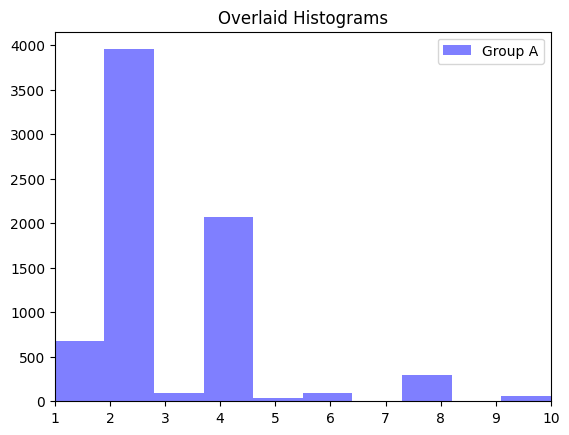

In [51]:
offlinemax_column = offlinemax_column[(1 <= offlinemax_column) & (offlinemax_column <= 10)]

plt.hist(offlinemax_column, alpha=0.5, label='Group A', color='blue')

plt.legend(loc='upper right')
plt.title('Overlaid Histograms')
plt.xlim(1,10)
plt.show()

None of these games actually support over 100 players; we need to drop these outliers.

### Online multiplayer

In [52]:
onlinemax_column = modes_df['onlinemax'].sort_values(ascending = False)
outliers = onlinemax_column.iloc[:20]

In [53]:
max_games = modes_df.loc[outliers.index]
max_games

,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
12075,22036,231860,False,False,False,0,0,False,0,5000,6,False
20902,33902,342779,True,False,False,0,0,False,0,5000,82,False
23498,40345,396231,False,False,False,0,0,True,5000,5000,82,False
4936,11838,139279,False,False,False,0,0,False,0,5000,6,False
12458,22691,190890,False,False,False,0,0,False,0,5000,6,False
11248,20827,218762,False,False,False,0,0,True,5000,5000,6,False
14667,33323,337715,False,False,True,5,5,True,5,5000,6,False
12074,22035,231860,False,False,False,0,0,False,0,5000,82,False
8585,16949,182119,False,False,False,0,0,False,0,4000,39,False
8586,16950,182119,False,False,False,0,0,False,0,4000,34,False


In [54]:
max_games.merge(games_df, how = 'left', left_on = 'game', right_on = 'id')['name']

0                   Nitro: Stream Racing
1                               Metacube
2                             Zero-G MMO
3                          Origin Online
4                     Legendarium Online
5                           Vs Chat Pack
6                               TakeDogs
7                   Nitro: Stream Racing
8                         Ultimate Golf!
9                         Ultimate Golf!
10                         Voxel Horizon
11    Warhammer Online: Age of Reckoning
12                             Castaways
13                       Ragnarok Online
14                             Polyblicy
15                        The Bingo Room
16                             Polyblicy
17                           KKuTuDotNet
18                                RigorZ
19                            Other Life
Name: name, dtype: str

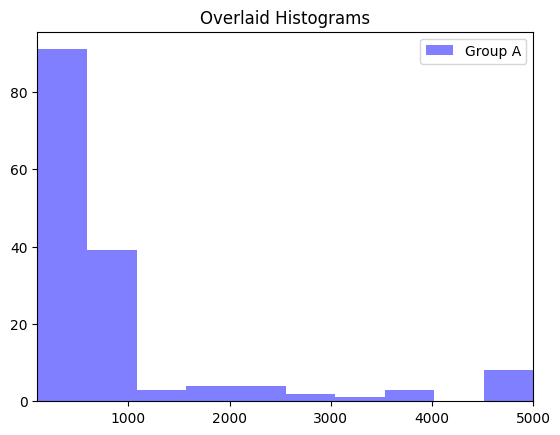

In [55]:
onlinemax_column = onlinemax_column[(100 < onlinemax_column) & (onlinemax_column < 10000)]

plt.hist(onlinemax_column, alpha=0.5, label='Group A', color='blue')

plt.legend(loc='upper right')
plt.title('Overlaid Histograms')
plt.xlim(100, 5000)
plt.show()

After some testing, 5000 seems to be the sweet spot where obviously incorrect data is dropped, leaving only games with truly very high player counts (basically just MMOs)

## Data in Multiplayer Modes that isn't in Games

In [ ]:
excluded_ids_mask = ~modes_df['game_id'].isin(games_df['id'])